CSPRNG COM PYTHON SECRETS

Primeiros 100 bits:
1101111010110000111010100101101110111001110100100000100010101100101011101101001110011100101110111010

Total de bits: 10000
Quantidade de zeros: 4996
Quantidade de uns: 5004
P(0): 0.499600
P(1): 0.500400


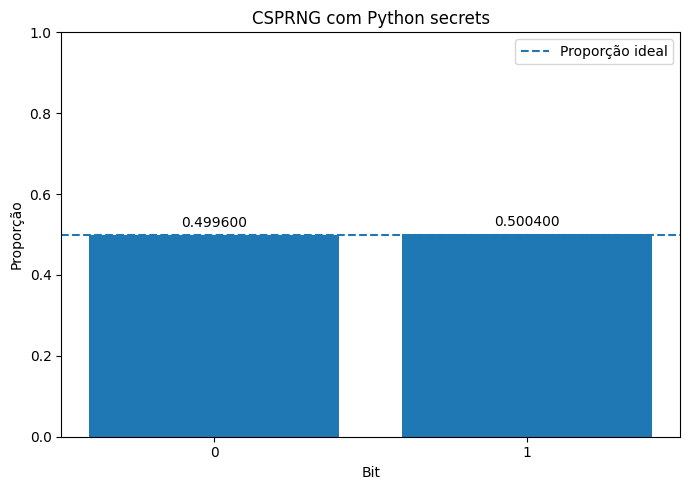

In [1]:
# CSPRNG COM PYTHON SECRETS

import secrets
import matplotlib.pyplot as plt


QUANTIDADE_BITS = 10000


# Geração dos bits

bits = [
    secrets.randbits(1)
    for _ in range(QUANTIDADE_BITS)
]


# Contagem

quantidade_zeros = bits.count(0)
quantidade_uns = bits.count(1)

total = len(bits)

p_zero = quantidade_zeros / total
p_um = quantidade_uns / total


# Resultados

print("CSPRNG COM PYTHON SECRETS")

print("\nPrimeiros 100 bits:")
print("".join(map(str, bits[:100])))

print(f"\nTotal de bits: {total}")
print(f"Quantidade de zeros: {quantidade_zeros}")
print(f"Quantidade de uns: {quantidade_uns}")
print(f"P(0): {p_zero:.6f}")
print(f"P(1): {p_um:.6f}")


# Gráfico

categorias = ["0", "1"]

valores = [
    p_zero,
    p_um
]

plt.figure(figsize=(7, 5))

barras = plt.bar(
    categorias,
    valores
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Proporção ideal"
)

plt.title(
    "CSPRNG com Python secrets"
)

plt.xlabel("Bit")
plt.ylabel("Proporção")

plt.ylim(0, 1)

plt.legend()

for barra, valor in zip(
    barras,
    valores
):
    plt.text(
        barra.get_x()
        + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.6f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

CSPRNG COM SYSTEMRANDOM

Primeiros 100 bits:
1100000001100111000011111011111111001001110101011100100101011000100100110010000011000110000010000110

Total de bits: 10000
Quantidade de zeros: 5010
Quantidade de uns: 4990
P(0): 0.501000
P(1): 0.499000


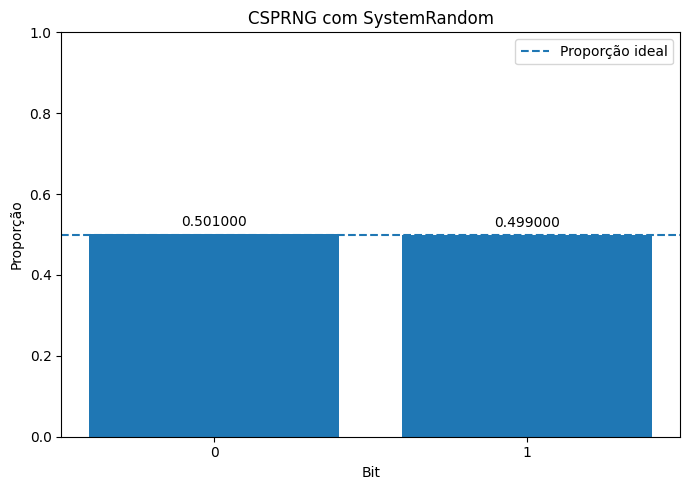

In [2]:
# CSPRNG COM SYSTEMRANDOM

import random
import matplotlib.pyplot as plt


QUANTIDADE_BITS = 10000


# Criação do gerador seguro

gerador = random.SystemRandom()


# Geração dos bits

bits = [
    gerador.randint(0, 1)
    for _ in range(QUANTIDADE_BITS)
]


# Contagem

quantidade_zeros = bits.count(0)
quantidade_uns = bits.count(1)

total = len(bits)

p_zero = quantidade_zeros / total
p_um = quantidade_uns / total


# Resultados

print("CSPRNG COM SYSTEMRANDOM")

print("\nPrimeiros 100 bits:")
print("".join(map(str, bits[:100])))

print(f"\nTotal de bits: {total}")
print(f"Quantidade de zeros: {quantidade_zeros}")
print(f"Quantidade de uns: {quantidade_uns}")
print(f"P(0): {p_zero:.6f}")
print(f"P(1): {p_um:.6f}")


# Gráfico

categorias = ["0", "1"]

valores = [
    p_zero,
    p_um
]

plt.figure(figsize=(7, 5))

barras = plt.bar(
    categorias,
    valores
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Proporção ideal"
)

plt.title(
    "CSPRNG com SystemRandom"
)

plt.xlabel("Bit")
plt.ylabel("Proporção")

plt.ylim(0, 1)

plt.legend()

for barra, valor in zip(
    barras,
    valores
):
    plt.text(
        barra.get_x()
        + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.6f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

FONTE SEGURA DO SISTEMA OPERACIONAL COM OS.URANDOM

Primeiros 100 bits:
0000001100010111100010110011100100111111101110011011111110111101110111100010011101010000010010000000

Total de bits: 10000
Quantidade de zeros: 5045
Quantidade de uns: 4955
P(0): 0.504500
P(1): 0.495500


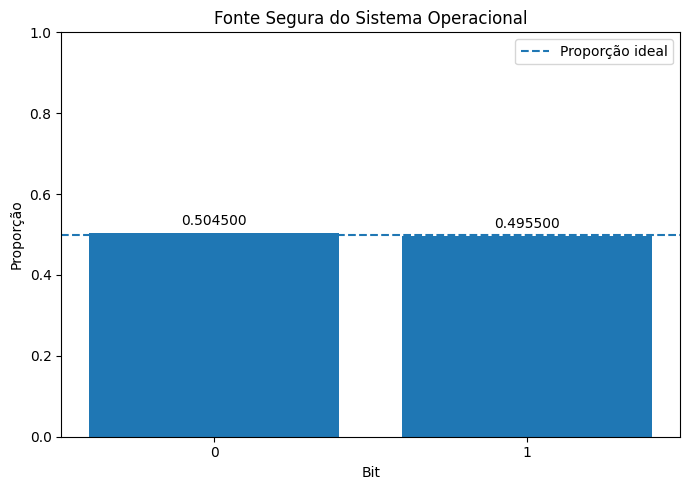

In [3]:
# FONTE SEGURA DO SISTEMA OPERACIONAL COM OS.URANDOM

import os
import matplotlib.pyplot as plt


QUANTIDADE_BITS = 10000


# Quantidade de bytes necessários

quantidade_bytes = (
    QUANTIDADE_BITS + 7
) // 8


# Coleta de bytes do sistema operacional

dados = os.urandom(
    quantidade_bytes
)


# Conversão para bits

bits = []

for byte in dados:

    for posicao in range(7, -1, -1):

        bit = (
            byte >> posicao
        ) & 1

        bits.append(bit)


# Remove bits excedentes

bits = bits[
    :QUANTIDADE_BITS
]


# Contagem

quantidade_zeros = bits.count(0)
quantidade_uns = bits.count(1)

total = len(bits)

p_zero = quantidade_zeros / total
p_um = quantidade_uns / total


# Resultados

print(
    "FONTE SEGURA DO SISTEMA OPERACIONAL "
    "COM OS.URANDOM"
)

print("\nPrimeiros 100 bits:")
print("".join(map(str, bits[:100])))

print(f"\nTotal de bits: {total}")
print(f"Quantidade de zeros: {quantidade_zeros}")
print(f"Quantidade de uns: {quantidade_uns}")
print(f"P(0): {p_zero:.6f}")
print(f"P(1): {p_um:.6f}")


# Gráfico

categorias = ["0", "1"]

valores = [
    p_zero,
    p_um
]

plt.figure(figsize=(7, 5))

barras = plt.bar(
    categorias,
    valores
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Proporção ideal"
)

plt.title(
    "Fonte Segura do Sistema Operacional"
)

plt.xlabel("Bit")
plt.ylabel("Proporção")

plt.ylim(0, 1)

plt.legend()

for barra, valor in zip(
    barras,
    valores
):
    plt.text(
        barra.get_x()
        + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.6f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Experimento padronizado

30 lotes × 10.000 bits usando `secrets` como baseline criptográfico. Os demais exemplos do notebook foram preservados.


In [4]:

import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels
import scipy


NUM_LOTES = 30
BITS_POR_LOTE = 10_000
ALFA = 0.05
Z_95 = 1.959963984540054

print("Python/ambiente estatístico:")
print("statsmodels:", statsmodels.__version__)
print("scipy:", scipy.__version__)


def intervalo_wilson(p, n, z=Z_95):
    if n == 0:
        return np.nan, np.nan

    denominador = 1 + (z ** 2) / n
    centro = (p + (z ** 2) / (2 * n)) / denominador
    margem = (
        z
        * math.sqrt(
            (p * (1 - p) + (z ** 2) / (4 * n))
            / n
        )
        / denominador
    )

    return centro - margem, centro + margem


def runs_test(bits):
    """
    Runs Test (Wald-Wolfowitz) usando statsmodels.

    H0: a ordem dos bits é compatível com aleatoriedade em relação
        ao número de corridas.
    H1: o número de corridas difere do esperado sob H0.

    Regra de decisão:
        p >= ALFA -> não rejeita H0
        p <  ALFA -> rejeita H0
    """
    from statsmodels.sandbox.stats.runs import runstest_1samp

    vetor = np.fromiter(
        (1 if bit == "1" else 0 for bit in bits),
        dtype=np.int8
    )

    if len(vetor) < 2 or np.all(vetor == vetor[0]):
        return np.nan, np.nan, np.nan

    numero_runs = 1 + int(np.sum(vetor[1:] != vetor[:-1]))

    z, p_valor = runstest_1samp(
        vetor,
        cutoff=0.5,
        correction=False
    )

    return numero_runs, float(z), float(p_valor)



def calcular_metricas(bits, fonte, lote, condicao="bruta"):
    bits = "".join(bits)

    n = len(bits)

    if n == 0:
        raise ValueError("O lote não contém bits.")

    zeros = bits.count("0")
    uns = bits.count("1")

    p0 = zeros / n
    p1 = uns / n

    vies = abs(p1 - 0.5)

    shannon = 0.0

    for p in (p0, p1):
        if p > 0:
            shannon -= p * math.log2(p)

    min_entropia = -math.log2(
        max(p0, p1)
    )

    vetor = np.fromiter(
        (1 if bit == "1" else 0 for bit in bits),
        dtype=np.float64
    )

    if (
        n > 1
        and np.std(vetor[:-1]) > 0
        and np.std(vetor[1:]) > 0
    ):
        autocorrelacao_lag1 = float(
            np.corrcoef(
                vetor[:-1],
                vetor[1:]
            )[0, 1]
        )
    else:
        autocorrelacao_lag1 = np.nan

    numero_runs, runs_z, runs_p_valor = runs_test(bits)

    ic95_inferior, ic95_superior = intervalo_wilson(
        p1,
        n
    )

    return {
        "fonte": fonte,
        "condicao": condicao,
        "lote": lote,
        "n_bits": n,
        "zeros": zeros,
        "uns": uns,
        "p0": p0,
        "p1": p1,
        "vies": vies,
        "ic95_p1_inferior": ic95_inferior,
        "ic95_p1_superior": ic95_superior,
        "entropia_shannon": shannon,
        "min_entropia_empirica": min_entropia,
        "autocorrelacao_lag1": autocorrelacao_lag1,
        "numero_runs": numero_runs,
        "runs_z": runs_z,
        "runs_p_valor": runs_p_valor,
        "runs_aprovado_alfa_005": (
            runs_p_valor >= ALFA
            if not np.isnan(runs_p_valor)
            else False
        ),
    }


def salvar_lote(bits, pasta, nome):
    pasta = Path(pasta)
    pasta.mkdir(
        parents=True,
        exist_ok=True
    )

    caminho = pasta / nome

    caminho.write_text(
        "".join(bits),
        encoding="utf-8"
    )

    return caminho


def resumo_metricas(df):
    colunas = [
        "p1",
        "vies",
        "entropia_shannon",
        "min_entropia_empirica",
        "autocorrelacao_lag1",
        "runs_z",
        "runs_p_valor",
    ]

    print("\nResumo dos 30 lotes:")
    display(
        df[colunas]
        .agg(["mean", "std", "min", "median", "max"])
        .T
    )

    print(
        "\nProporção de aprovação no Runs Test (alfa = 0,05):",
        f"{df['runs_aprovado_alfa_005'].mean():.2%}"
    )


# EXPERIMENTO PADRONIZADO — CSPRNG

import secrets

FONTE = "CSPRNG_Python_secrets"

pasta_saida = Path(
    "/content/dados_padronizados/csprng"
)

resultados = []

for lote in range(1, NUM_LOTES + 1):

    bits = "".join(
        str(secrets.randbits(1))
        for _ in range(BITS_POR_LOTE)
    )

    salvar_lote(
        bits,
        pasta_saida,
        f"csprng_lote_{lote:02d}.txt"
    )

    resultados.append(
        calcular_metricas(
            bits,
            fonte=FONTE,
            lote=lote
        )
    )

df_csprng = pd.DataFrame(resultados)

caminho_csv = (
    pasta_saida
    / "csprng_metricas_30x10000.csv"
)

df_csprng.to_csv(
    caminho_csv,
    index=False
)

print("Experimento concluído.")
print("Fonte principal: Python secrets")
print("Lotes:", NUM_LOTES)
print("Bits por lote:", BITS_POR_LOTE)
print("Total de bits:", NUM_LOTES * BITS_POR_LOTE)
print("CSV:", caminho_csv)

display(df_csprng.head())

resumo_metricas(df_csprng)


Python/ambiente estatístico:
statsmodels: 0.14.6
scipy: 1.16.3
Experimento concluído.
Fonte principal: Python secrets
Lotes: 30
Bits por lote: 10000
Total de bits: 300000
CSV: /content/dados_padronizados/csprng/csprng_metricas_30x10000.csv


,fonte,condicao,lote,n_bits,zeros,uns,p0,p1,vies,ic95_p1_inferior,ic95_p1_superior,entropia_shannon,min_entropia_empirica,autocorrelacao_lag1,numero_runs,runs_z,runs_p_valor,runs_aprovado_alfa_005
0,CSPRNG_Python_secrets,bruta,1,10000,4979,5021,0.4979,0.5021,0.0021,0.492301,0.511897,0.999987,0.993953,-0.003317,5017,0.321786,0.747615,True
1,CSPRNG_Python_secrets,bruta,2,10000,4894,5106,0.4894,0.5106,0.0106,0.500800,0.520392,0.999676,0.969735,-0.001150,5004,0.104996,0.916379,True
2,CSPRNG_Python_secrets,bruta,3,10000,4981,5019,0.4981,0.5019,0.0019,0.492101,0.511697,0.999990,0.994528,0.006686,4967,-0.678600,0.497392,True
3,CSPRNG_Python_secrets,bruta,4,10000,5082,4918,0.5082,0.4918,0.0082,0.482007,0.501600,0.999806,0.976532,0.011238,4943,-1.133466,0.257019,True
4,CSPRNG_Python_secrets,bruta,5,10000,5033,4967,0.5033,0.4967,0.0033,0.486904,0.506499,0.999969,0.990509,-0.003944,5020,0.384392,0.700688,True



Resumo dos 30 lotes:


,mean,std,min,median,max
p1,0.500803,0.005534,0.490200,0.500050,0.510900
vies,0.004503,0.003211,0.000200,0.003550,0.010900
entropia_shannon,0.999913,0.000103,0.999657,0.999964,1.000000
min_entropia_empirica,0.987092,0.009168,0.968887,0.989793,0.999423
autocorrelacao_lag1,-0.002935,0.008260,-0.019324,-0.002865,0.014237
runs_z,0.283458,0.825942,-1.433444,0.276530,1.922253
runs_p_valor,0.550385,0.291549,0.054574,0.550513,0.988122



Proporção de aprovação no Runs Test (alfa = 0,05): 100.00%
